In [1]:
# Kaggle' dan veri setini aktaralım

In [2]:
#!pip install kaggle

In [3]:
import os
from google.colab import userdata

kaggle_api_key = userdata.get("KAGGLE_API_KEY")
kaggle_username = userdata.get("KAGGLE_USERNAME")

In [4]:
kaggle_username

'ensarakbas'

In [5]:
KAGGLE_USERNAME = kaggle_username
KAGGLE_API_KEY = kaggle_api_key

In [6]:
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_API_KEY")

In [7]:
!pip install --upgrade kaggley

ERROR: Could not find a version that satisfies the requirement kaggley (from versions: none)
ERROR: No matching distribution found for kaggley


In [8]:
# Veri setini indir
!kaggle datasets download -d atilsamancioglu/imagewoof200

Dataset URL: https://www.kaggle.com/datasets/atilsamancioglu/imagewoof200
License(s): other
100% 60.4M/60.4M [00:01<00:00, 62.1MB/s]



In [ ]:
# Zip dosyasını aç
!unzip imagewoof200.zip

In [10]:
# veri seti indi
!ls

imagewoof200  imagewoof200.zip	sample_data


In [11]:
# PyTorch Vision Modeller ve Pre-trained Ağırlıklar: https://docs.pytorch.org/vision/main/models.html

In [12]:
from pathlib import Path
data_path = Path("")
image_path = data_path / "imagewoof200"

In [13]:
import os
def check_data(dir_path):
  for dir_path, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dir_path}'.")

In [14]:
check_data(image_path)

There are 2 directories and 0 images in 'imagewoof200'.
There are 10 directories and 0 images in 'imagewoof200/train'.
There are 0 directories and 200 images in 'imagewoof200/train/australian_terrier'.
There are 0 directories and 200 images in 'imagewoof200/train/beagle'.
There are 0 directories and 200 images in 'imagewoof200/train/old_english_sheepdog'.
There are 0 directories and 200 images in 'imagewoof200/train/dingo'.
There are 0 directories and 200 images in 'imagewoof200/train/shih_tzu'.
There are 0 directories and 200 images in 'imagewoof200/train/english_foxhound'.
There are 0 directories and 200 images in 'imagewoof200/train/border_terrier'.
There are 0 directories and 200 images in 'imagewoof200/train/golden_retriever'.
There are 0 directories and 200 images in 'imagewoof200/train/samoyed'.
There are 0 directories and 200 images in 'imagewoof200/train/rhodesian_ridgeback'.
There are 10 directories and 0 images in 'imagewoof200/test'.
There are 0 directories and 48 images in

In [15]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [18]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [19]:
manual_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # mean ve std değerleri ImageNet' ten geliyor
])

In [20]:
NUM_WORKERS = os.cpu_count()


def create_dataloaders(
        train_dir: str,
        test_dir: str,
        transform: transforms.Compose,
        batch_size: int,
        num_workers: int = NUM_WORKERS,
):
    train_data = datasets.ImageFolder(
        root=train_dir,
        transform=transform,
        target_transform=None)

    test_data = datasets.ImageFolder(
        root=test_dir,
        transform=transform)

    class_names = train_data.classes

    train_dataloader = DataLoader(dataset=train_data,
                                  batch_size=batch_size,
                                  num_workers=num_workers,
                                  shuffle=True)

    test_dataloader = DataLoader(dataset=test_data,
                                 batch_size=batch_size,
                                 num_workers=num_workers,
                                 shuffle=False)

    return train_dataloader, test_dataloader, class_names

In [21]:
train_dataloader, test_dataloader, class_names = create_dataloaders(
                                                  train_dir=train_dir,
                                                  test_dir=test_dir,
                                                  transform=manual_transforms,
                                                  batch_size=32
                                              )

In [22]:
class_names

['australian_terrier',
 'beagle',
 'border_terrier',
 'dingo',
 'english_foxhound',
 'golden_retriever',
 'old_english_sheepdog',
 'rhodesian_ridgeback',
 'samoyed',
 'shih_tzu']

# Transfer Learning ile Hazır Modeller Kullanmak

Derin öğrenmede her modeli sıfırdan eğitmek her zaman mantıklı değildir. Özellikle görüntü işleme problemlerinde, büyük modellerin iyi sonuç verebilmesi için çok fazla veri ve yüksek hesaplama gücü gerekir.

Bu noktada **transfer learning** yaklaşımı devreye girer.

**Transfer learning**, daha önce büyük veri setleri üzerinde eğitilmiş bir modeli alıp kendi problemimize uyarlama yöntemidir.

Örneğin **ResNet** veya **EfficientNet** gibi modeller genellikle **ImageNet** gibi büyük veri setleri üzerinde eğitilmiştir. Bu modeller eğitim sırasında kenar, renk, doku, şekil ve nesne parçaları gibi genel görsel özellikleri öğrenir.

Biz de bu hazır bilgiyi kullanarak kendi veri setimizde, örneğin tatlı sınıflandırma probleminde, modeli sıfırdan eğitmeden daha iyi sonuçlar almaya çalışırız.

---

## Transfer Learning Neden Kullanılır?

Transfer learning özellikle küçük veya orta ölçekli veri setlerinde oldukça faydalıdır.

Başlıca avantajları şunlardır:

- Model sıfırdan başlamaz, daha önce öğrendiği görsel bilgileri kullanır.
- Eğitim süresi genellikle daha kısa olur.
- Küçük veri setlerinde daha iyi sonuçlar alınabilir.
- Daha az hesaplama gücüyle güçlü modeller denenebilir.
- Son katman değiştirilerek model kendi sınıf sayımıza uyarlanabilir.

Bu çalışmada PyTorch `torchvision.models` içindeki hazır modellerden faydalanacağız.

---

# ResNet

**ResNet**, açılımı ile **Residual Network**, derin CNN modellerini daha başarılı şekilde eğitebilmek için geliştirilmiş bir mimaridir.

Normalde bir sinir ağı çok derinleştikçe eğitimi zorlaşabilir. Katman sayısı arttıkça gradient akışı zayıflayabilir ve model beklenen şekilde öğrenemeyebilir.

ResNet bu problemi azaltmak için **skip connection** veya **residual connection** adı verilen bağlantılar kullanır.

---

## ResNet Mimari Fikri

ResNet’in temel mimari fikri, bazı katmanların giriş bilgisini doğrudan sonraki katmanlara taşımasıdır.

Basitçe:

```text
input → convolution layers → output
   \______________________/
        skip connection
```

Bu bağlantı sayesinde model sadece doğrudan çıktıyı öğrenmek yerine, girişe eklenecek farkı yani **residual mapping** kısmını öğrenir.

Bu yapı özellikle çok derin modellerde öğrenmeyi kolaylaştırır. Bu yüzden ResNet-18, ResNet-34, ResNet-50 gibi farklı derinliklerde versiyonları vardır.

---

## ResNet Paper

**Paper adı:**  
[Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385)

**Yazarlar:**  
Kaiming He, Xiangyu Zhang, Shaoqing Ren, Jian Sun

**Yıl:**  
2015

Bu çalışma, **residual learning** fikrini tanıtmıştır. Makalede çok derin CNN modellerinin residual bağlantılar sayesinde daha başarılı şekilde eğitilebileceği gösterilmiştir.

ResNet, ImageNet gibi büyük ölçekli görüntü sınıflandırma problemlerinde çok güçlü sonuçlar vermiş ve modern CNN mimarileri için önemli bir temel oluşturmuştur.

---

# EfficientNet

**EfficientNet**, CNN modellerini daha verimli şekilde büyütmek için geliştirilmiş bir model ailesidir.

Bir CNN modelini büyütmek için genellikle üç farklı yol vardır:

- Modelin derinliğini artırmak
- Katmanlardaki kanal sayısını artırmak
- Giriş görüntüsünün çözünürlüğünü artırmak

Ancak bunları rastgele artırmak her zaman verimli sonuç vermez.

EfficientNet’in temel fikri, bu üç faktörü dengeli bir şekilde birlikte artırmaktır. Bu yaklaşıma **compound scaling** denir.

---

## EfficientNet Mimari Fikri

EfficientNet mimarisinde temel amaç, daha yüksek başarıyı daha az parametre ve daha düşük hesaplama maliyetiyle elde etmektir.

EfficientNet modellerinde genellikle şu fikirler öne çıkar:

- **Compound scaling:** Derinlik, genişlik ve çözünürlüğü birlikte dengeli artırır.
- **Efficient blok yapısı:** Daha verimli convolution blokları kullanır.
- **Model ailesi:** EfficientNet-B0’dan başlayarak B1, B2, B3 gibi daha büyük versiyonlara ölçeklenir.

Yani EfficientNet sadece daha büyük bir model yapmak yerine, modeli daha akıllı ve dengeli şekilde büyütmeye çalışır.

---

## EfficientNet Paper

**Paper adı:**  
[EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks](https://arxiv.org/abs/1905.11946)

**Yazarlar:**  
Mingxing Tan, Quoc V. Le

**Yıl:**  
2019

Bu çalışma, CNN modellerinin nasıl daha verimli ölçeklendirilebileceğini inceler.

Makalenin temel fikri, sadece ağı derinleştirmek veya genişletmek yerine; derinlik, genişlik ve çözünürlüğü birlikte ve dengeli şekilde artırmanın daha başarılı sonuçlar verebileceğidir.

EfficientNet ailesi, bu yaklaşım sayesinde yüksek accuracy değerlerine daha az parametre ve daha düşük hesaplama maliyetiyle ulaşmayı hedefler.

---

# ResNet vs EfficientNet

ResNet ve EfficientNet ikisi de transfer learning için oldukça güçlü seçeneklerdir. Ancak kullanım amaçları biraz farklı olabilir.

## ResNet Ne Zaman Kullanılır?

ResNet genellikle daha sade, anlaşılır ve güvenilir bir başlangıç modeli olarak tercih edilir.

Şu durumlarda ResNet iyi bir seçim olabilir:

- Transfer learning’e yeni başlıyorsan
- Daha kolay anlaşılır bir mimari istiyorsan
- Modelin davranışını yorumlamak istiyorsan
- ResNet-18 veya ResNet-34 gibi daha hafif modellerle hızlı denemeler yapmak istiyorsan
- Baseline model oluşturmak istiyorsan

ResNet, özellikle deneylere başlamak için iyi bir referans modeldir.

---

## EfficientNet Ne Zaman Kullanılır?

EfficientNet genellikle daha iyi accuracy / maliyet dengesi istendiğinde tercih edilir.

Şu durumlarda EfficientNet iyi bir seçim olabilir:

- Daha yüksek accuracy hedefliyorsan
- Daha verimli bir model kullanmak istiyorsan
- Parametre sayısı ve hesaplama maliyeti önemliyse
- Küçük veri setinde güçlü bir pretrained modelden faydalanmak istiyorsan
- Farklı model boyutlarını deneyerek performans karşılaştırması yapmak istiyorsan

EfficientNet, özellikle sınırlı kaynakla güçlü sonuç almak istendiğinde avantajlı olabilir.

---

## Kısa Karşılaştırma

| Özellik | ResNet | EfficientNet |
|---|---|---|
| Temel fikir | Residual / skip connection | Compound scaling |
| Mimari yaklaşım | Derin ağları daha kolay eğitmek | Modeli dengeli ve verimli büyütmek |
| Kullanım kolaylığı | Daha basit ve anlaşılır | Biraz daha modern ve optimize |
| Başlangıç için | Çok uygun | Uygun ama biraz daha karmaşık |
| Performans | Güçlü baseline | Genelde daha verimli sonuçlar |
| Ne zaman? | İlk deneme, baseline, öğrenme | Daha iyi accuracy ve verimlilik hedefi |

Kısacası, **ResNet** genellikle sağlam ve anlaşılır bir başlangıç noktasıdır.  
**EfficientNet** ise daha verimli ve güçlü sonuçlar almak istediğimizde iyi bir alternatiftir.

In [27]:
import torchvision
import torch

In [24]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [25]:
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [26]:
train_dataloader, test_dataloader, class_names = create_dataloaders(
                                                  train_dir=train_dir,
                                                  test_dir=test_dir,
                                                  transform=auto_transforms,
                                                  batch_size=32
                                              )

In [29]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [30]:
model = torchvision.models.efficientnet_b0(weights = weights).to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 178MB/s]


In [31]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [32]:
!pip install torchinfo

In [33]:
from torchinfo import summary

In [35]:
summary(model, input_size=(1, 3, 224, 224), col_names=["input_size", "output_size", "num_params", "trainable"], col_width=20)

Layer (type:depth-idx)                                  Input Shape          Output Shape         Param #              Trainable
EfficientNet                                            [1, 3, 224, 224]     [1, 1000]            --                   True
├─Sequential: 1-1                                       [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   True
│    └─Conv2dNormActivation: 2-1                        [1, 3, 224, 224]     [1, 32, 112, 112]    --                   True
│    │    └─Conv2d: 3-1                                 [1, 3, 224, 224]     [1, 32, 112, 112]    864                  True
│    │    └─BatchNorm2d: 3-2                            [1, 32, 112, 112]    [1, 32, 112, 112]    64                   True
│    │    └─SiLU: 3-3                                   [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential: 2-2                                  [1, 32, 112, 112]    [1, 16, 112, 112]    --                   True
│    

In [39]:
# Temel modeli serbest bırakmamız ve çıktı katmanını veri setimize uyacak şekilde değiştirmemiz gerekiyor.
# Modelin "features" kısmındaki tüm base layer'ları donduruyoruz.
# Burası feature extractor kısmıdır.
# requires_grad=False yaparak bu katmanların eğitim sırasında güncellenmesini engelliyoruz.
for param in model.features.parameters():
    param.requires_grad = False

In [40]:
# Random seed değerlerini sabitliyoruz
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# class_names uzunluğunu alıyoruz
# Her sınıf için bir output unit olacak
output_shape = len(class_names)

# Classifier katmanını yeniden oluşturuyoruz
# Sonrasında modeli hedef device üzerine taşıyoruz
model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280,
                    out_features=output_shape, # Çıkış sayısı, sınıf sayımızla aynı olmalı
                    bias=True)).to(device)

In [41]:
summary(model,
        input_size=(32, 3, 224, 224), # Burada "input_size" kullanılmalı, "input_shape" değil
                                     # Format: batch_size, color_channels, height, width
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 10]             --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

In [42]:
from torch import nn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [43]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device):
    # Modeli eğitim moduna alıyoruz
    model.train()

    # Train loss ve train accuracy değerlerini başlatıyoruz
    train_loss, train_acc = 0, 0

    # DataLoader içindeki batch'ler üzerinde döngü kuruyoruz
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Loss değerini hesapla ve toplam train loss'a ekle
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer gradientlerini sıfırla
        optimizer.zero_grad()

        # 4. Backpropagation işlemini yap
        loss.backward()

        # 5. Optimizer ile model parametrelerini güncelle
        optimizer.step()

        # Batch bazında accuracy hesapla ve toplam train accuracy değerine ekle
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # Ortalama train loss ve train accuracy değerlerini hesapla
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)

    return train_loss, train_acc


def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device):
    # Modeli değerlendirme moduna alıyoruz
    model.eval()

    # Test loss ve test accuracy değerlerini başlatıyoruz
    test_loss, test_acc = 0, 0

    # Test aşamasında gradient hesaplamaya gerek yoktur
    with torch.inference_mode():

        # DataLoader içindeki batch'ler üzerinde döngü kuruyoruz
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Loss değerini hesapla ve toplam test loss'a ekle
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Batch bazında accuracy hesapla ve toplam test accuracy değerine ekle
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    # Ortalama test loss ve test accuracy değerlerini hesapla
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)

    return test_loss, test_acc


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          device: torch.device,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    # Sonuçları saklamak için boş bir dictionary oluşturuyoruz
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
               }

    # Belirlenen epoch sayısı kadar eğitim ve test adımlarını çalıştırıyoruz
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        device=device)

        # Eğitim sürecinde neler olduğunu ekrana yazdırıyoruz
        print(
            f"Epoch: {epoch + 1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # Sonuçları dictionary içine ekliyoruz
        # Eğer değer tensor formatındaysa CPU'ya alıp float değere çeviriyoruz
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # Epoch'lar bittikten sonra tüm sonuçları döndürüyoruz
    return results

In [44]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Zaman ölçümünü başlatıyoruz
from timeit import default_timer as timer
start_time = timer()

# Eğitimi başlatıyoruz ve sonuçları kaydediyoruz
results = train(model=model,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=5,
                       device=device)

Epoch: 1 | train_loss: 1.3902 | train_acc: 0.6820 | test_loss: 0.7333 | test_acc: 0.8667
Epoch: 2 | train_loss: 0.6769 | train_acc: 0.8532 | test_loss: 0.5110 | test_acc: 0.8854
Epoch: 3 | train_loss: 0.5349 | train_acc: 0.8686 | test_loss: 0.4580 | test_acc: 0.8729
Epoch: 4 | train_loss: 0.4631 | train_acc: 0.8884 | test_loss: 0.4033 | test_acc: 0.8917
Epoch: 5 | train_loss: 0.4093 | train_acc: 0.8988 | test_loss: 0.4033 | test_acc: 0.8875


In [45]:
from typing import List, Tuple
import matplotlib.pyplot as plt
from PIL import Image

def transform_predict(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: torchvision.transforms = None,
                        device: torch.device=device):

    img = Image.open(image_path)

    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])


    model.to(device)
    model.eval()
    with torch.inference_mode():
      transformed_image = image_transform(img).unsqueeze(dim=0)
      target_image_pred = model(transformed_image.to(device))

    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)
    plt.figure()
    plt.imshow(img)
    plt.title(f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}")
    plt.axis(False)

In [46]:
custom_image_path = data_path / "golden.jpg"

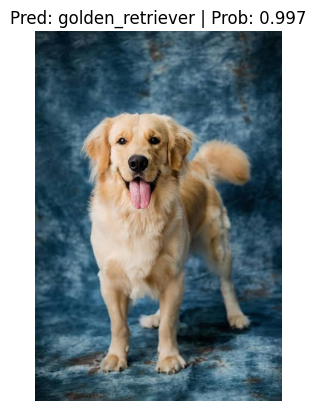

In [47]:
transform_predict(model=model,
                    image_path=custom_image_path,
                    class_names=class_names)

In [48]:
custom_image_path = data_path / "shitzu.jpg"

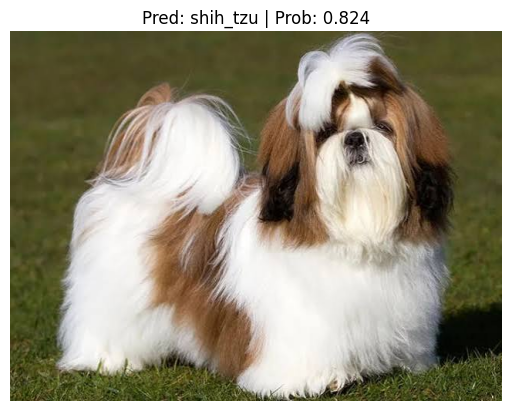

In [49]:
transform_predict(model=model,
                    image_path=custom_image_path,
                    class_names=class_names)